# Compare LLMs to baseline in Dragon Hunt use case

Baselines: rule-based MT

LLMs: gpt-4o-mini-2024-07-18, o3-mini-2025-01-31

In [1]:
!ls -l  # check that we are in the correct directory

total 27
-rw-r----- 1 root users  113 Nov  5 14:04 10steps.yaml
-rw-r----- 1 root users  109 Nov 22 08:50 5steps.yaml
-rw-r----- 1 root users   91 Nov 15 09:49 battery_and_charging_rl.yaml
-rw-r----- 1 root users  270 Nov 25 10:45 config_auto_charging_only.yaml
-rw-r----- 1 root users  230 Nov 25 10:45 config_auto_charging.yaml
-rw-r----- 1 root users   35 Nov 25 10:45 config_battery_and_charging.yaml
-rw-r----- 1 root users  142 Nov 25 10:45 config_no_battery.yaml
-rw-r----- 1 root users  162 Nov 25 10:45 default_old.yaml
-rw-r----- 1 root users  652 Nov 25 10:45 default.yaml
-rw-r----- 1 root users  619 Jan 20 15:07 drones.yaml
-rw-r----- 1 root users  250 Nov 22 08:50 goal_charging.yaml
-rw-r----- 1 root users  426 Nov 22 08:50 goal_full_protection.yaml
-rw-r----- 1 root users  901 Jan 24 14:11 goal_step_by_step.yaml
-rw-r----- 1 root users  257 Nov 25 10:45 goal_threat_level2.yaml
-rw-r----- 1 root users  564 Jan  9 09:36 goal_threat_level3_full_protection.yaml
-rw-r----- 1 root us

In [11]:
import subprocess
import os

def run(args, repeats=10, start=1):
    print(args)
    for repeat in range(repeats):
        print(f"  Run #{repeat + start}/{repeats + start - 1}")
        run = ["python", "main.py", *args, "-s", str(repeat + start), "-e", str(repeat + start)]
        # if repeat % 10 == 0:
        #     run.append("--animation")
        
        # disable TF errors
        env = dict(os.environ, TF_CPP_MIN_LOG_LEVEL="3")

        result = subprocess.run(run, capture_output=True, env=env)
        stdout = result.stdout.decode("utf-8")
        stderr = result.stderr.decode("utf-8")

        hp = stdout.partition("dragon_hp: ")[2].partition("\n")[0]
        print(f"    Dragon HP: {hp}")

        #print(stdout.partition("Simulation done\n")[2])
        # print(stdout)
        if stderr:
            print(stderr)

## Baselines

In [2]:
args = ["dragon/configs/default.yaml", "dragon/configs/rule_based_mt.yaml", "../configs/deepnote_0217.yaml"]
run(args, repeats=10)

['dragon/configs/default.yaml', 'dragon/configs/rule_based_mt.yaml', '../configs/deepnote_0102.yaml']
  Run #1/10
    Dragon HP: -7
  Run #2/10
    Dragon HP: -4
  Run #3/10
    Dragon HP: -7
  Run #4/10
    Dragon HP: -1
  Run #5/10
    Dragon HP: -4
  Run #6/10
    Dragon HP: -1
  Run #7/10
    Dragon HP: -10
  Run #8/10
    Dragon HP: -1
  Run #9/10
    Dragon HP: -4
  Run #10/10
    Dragon HP: -4


In [3]:
args = ["dragon/configs/default.yaml", "dragon/configs/rule_based_random.yaml", "../configs/deepnote_0217.yaml"]
run(args, repeats=10)

['dragon/configs/default.yaml', 'dragon/configs/rule_based_random.yaml', '../configs/deepnote_0102.yaml']
  Run #1/10
    Dragon HP: 9
  Run #2/10
    Dragon HP: 22
  Run #3/10
    Dragon HP: 25
  Run #4/10
    Dragon HP: 41
  Run #5/10
    Dragon HP: 12
  Run #6/10
    Dragon HP: 28
  Run #7/10
    Dragon HP: 31
  Run #8/10
    Dragon HP: 25
  Run #9/10
    Dragon HP: -5
  Run #10/10
    Dragon HP: 41


## LLMs

In [5]:
grid_params = {
    "llm": ["configs/llm_gpt4omini.yaml", "configs/llm_o3mini.yaml"],
    "strategy": [None, "dragon/configs/strategy.yaml"],
}

In [7]:
import itertools

grid = list(itertools.product(*grid_params.values()))
print(len(grid))

4


In [13]:
for i, params in enumerate(grid, start=1):
    print(f"{i}/{len(grid)}")

    args = ["dragon/configs/default.yaml", "configs/jinja.yaml", "DSL/dragon.yaml", 
        "dragon/configs/description2.yaml", "configs/retry1.yaml"]
    
    for param in params:
        if param is not None:
            args.append(param)

    args.append("../configs/deepnote_0310.yaml")  # this is just to save the results to a specific folder, it can be safely removed

    for config_file in args:
        assert os.path.exists(config_file), f"File {config_file} does not exist"
    
    run(args, repeats=3)
    # run(args, repeats=5, start=6)

1/4
['dragon/configs/default.yaml', 'configs/jinja.yaml', 'DSL/dragon.yaml', 'dragon/configs/description2.yaml', 'configs/retry1.yaml', 'configs/llm_gpt4omini.yaml', '../configs/deepnote_0310.yaml']
  Run #1/3
    Dragon HP: 28
  Run #2/3
    Dragon HP: 0
  Run #3/3
    Dragon HP: 35
2/4
['dragon/configs/default.yaml', 'configs/jinja.yaml', 'DSL/dragon.yaml', 'dragon/configs/description2.yaml', 'configs/retry1.yaml', 'configs/llm_gpt4omini.yaml', 'dragon/configs/strategy.yaml', '../configs/deepnote_0310.yaml']
  Run #1/3
    Dragon HP: 47
Unknown component: Warrior 1
Unknown component: Warrior 2
Invalid group for Villager in Village: "attack". It must be one of "farm", "cave", "spawn farmer", "spawn warrior".
Invalid group for Villager in Village: "attack". It must be one of "farm", "cave", "spawn farmer", "spawn warrior".
The following components have not been assigned to a group: Sarah, Carol

  Run #2/3
    Dragon HP: 17
  Run #3/3
    Dragon HP: 38
3/4
['dragon/configs/default.yaml

## Results - steps to kill Dragon

In [53]:
from pathlib import Path
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [54]:
baselines = {
    # "Rule-based Random": "../0217/logs/dragon/rule_based_random",
    "Rule-based MT": "../0217/logs/dragon/rule_based_mt",
}

In [55]:
results_folder = Path("../0310/logs/dragon")

In [56]:
results_files = sorted(results_folder.glob("*/*.csv"))
print(len(results_files), "files found")

12 files found


In [57]:
summary = pd.DataFrame(columns=["llm", "params", "steps", "hp"])

In [58]:
for baseline, folder in baselines.items():
    path = Path(folder)
    files = sorted(path.glob("*.csv"))

    for file in files:
        try:
            data = pd.read_csv(file)
            last_row = data.iloc[-1]
            step = last_row["step"]
            hp = last_row["dragon_hp"]
            
            llm = "baseline"
            params = baseline

            summary.loc[len(summary)] = [llm, params, step, hp]
        except pd.errors.EmptyDataError:
            print("Skipping empty file", file)
        except IndexError:
            print("Index error in file", file)

summary.to_csv(results_folder / "summary.csv", index=False)

In [59]:
for file in results_files:
    try:
        name = file.stem
        if "jinja" not in name:
            continue

        data = pd.read_csv(file)
        last_row = data.iloc[-1]
        step = last_row["step"]
        hp = last_row["dragon_hp"]
                
        parts = name.split("_")
        llm = parts[3]
        params = parts[4:]
        if params == []:
            params = ["Default"]
        params = ",\n".join(params)
        
        summary.loc[len(summary)] = [llm, params, step, hp]
    except pd.errors.EmptyDataError:
        print("Skipping empty file", file)
    except IndexError:
        print("Index error in file", file)

summary.to_csv(results_folder / "summary.csv", index=False)

In [60]:
summary = pd.read_csv(results_folder / "summary.csv")

In [61]:
palette = {
    "baseline": "tab:gray",
    "gpt4omini": "tab:red",
    "o3mini": "tab:purple",
}

In [62]:
llm_names = {
    "baseline": "Baseline",
    "gpt4omini": "GPT-4o mini",
    "o3mini": "OpenAI o3-mini",
}
summary['LLM'] = summary['llm'].map(llm_names)
palette_LLM = {v: palette[k] for k, v in llm_names.items()}

In [63]:
params = {
    "strategy": "Hinted",
}
summary['params'] = summary['params'].replace(params)

In [64]:
summary['Final Dragon HP'] = summary['hp'].where(summary['hp'] > 0, other=0)

In [65]:
summary

,llm,params,steps,hp,LLM,Final Dragon HP
0,baseline,Rule-based MT,11,-7,Baseline,0
1,baseline,Rule-based MT,9,-4,Baseline,0
2,baseline,Rule-based MT,16,-7,Baseline,0
3,baseline,Rule-based MT,12,-1,Baseline,0
4,baseline,Rule-based MT,9,-4,Baseline,0
5,baseline,Rule-based MT,13,-1,Baseline,0
6,baseline,Rule-based MT,15,-10,Baseline,0
7,baseline,Rule-based MT,14,-1,Baseline,0
8,baseline,Rule-based MT,10,-4,Baseline,0
9,baseline,Rule-based MT,11,-4,Baseline,0


In [109]:
summary[summary['steps'] != 30].groupby(["params", "LLM"])["steps"].count().reset_index()

,params,LLM,steps
0,Default,GPT-4o mini,1
1,Default,OpenAI o3-mini,1
2,Hinted,OpenAI o3-mini,3
3,Rule-based MT,Baseline,10


In [115]:
summary[summary['steps'] != 30].groupby(["params", "LLM"])["steps"].mean().reset_index()

,params,LLM,steps
0,Default,GPT-4o mini,19.0
1,Default,OpenAI o3-mini,11.0
2,Hinted,OpenAI o3-mini,14.0
3,Rule-based MT,Baseline,12.0


In [113]:
summary.groupby(["params", "LLM"])["steps"].mean().reset_index()

,params,LLM,steps
0,Default,GPT-4o mini,26.333333
1,Default,OpenAI o3-mini,23.666667
2,Hinted,GPT-4o mini,30.000000
3,Hinted,OpenAI o3-mini,14.000000
4,Rule-based MT,Baseline,12.000000


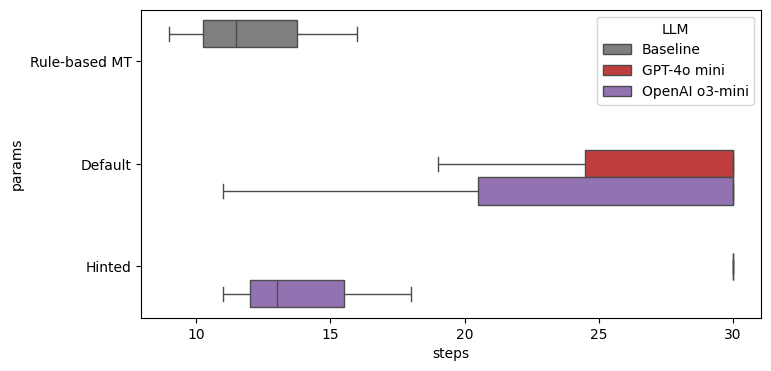

In [66]:
fig, ax = plt.subplots(figsize=(8, 4))
sns.boxplot(x="steps", y="params", hue="LLM", data=summary, ax=ax, palette=palette_LLM, hue_order=palette_LLM.keys())
plt.show()

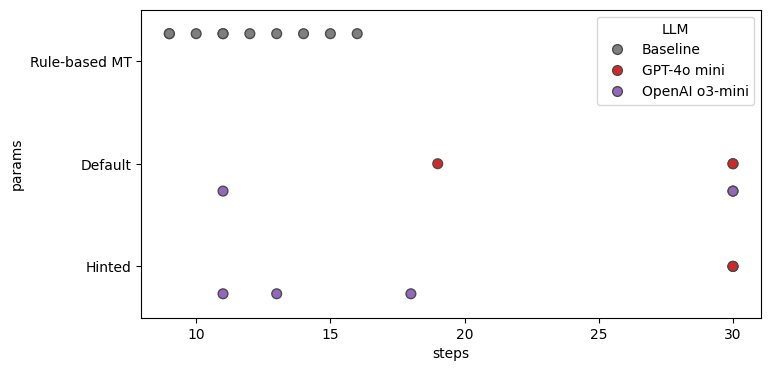

In [67]:
fig, ax = plt.subplots(figsize=(8, 4))
plot_kwargs = {
    "dodge": True,
    "jitter": False,
    "size": 7,
    "linewidth": 1,
}
sns.stripplot(x="steps", y="params", hue="LLM", data=summary, ax=ax, palette=palette_LLM, hue_order=palette_LLM.keys(), **plot_kwargs)
plt.show()

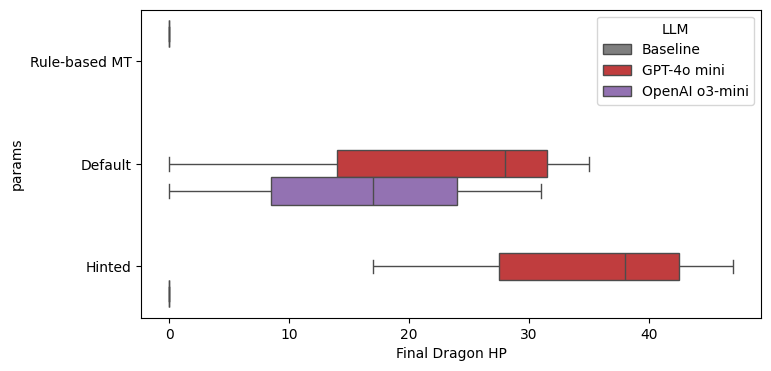

In [68]:
fig, ax = plt.subplots(figsize=(8, 4))
sns.boxplot(x='Final Dragon HP', y="params", hue="LLM", data=summary, ax=ax, palette=palette_LLM, hue_order=palette_LLM.keys())
plt.show()

## Results - errors and retries

In [78]:
errors = pd.DataFrame(columns=["llm", "params", "total", "final", "retries", "filename"])

In [80]:
log_files = sorted(results_folder.glob("*/*.ansi"))

for file in log_files:
    try:
        name = file.stem
        if "jinja" not in name:
            continue

        with open(file, 'r') as f:
            content = f.read()
            total = content.count("Before retry:")
            final = content.count("Error in final assignment:")
            retries = content.count("There were some errors in your final group assignment.")
                

        parts = name.split("_")
        llm = parts[3]
        params = parts[4:]
        if params == []:
            params = ["Default"]
        params = ",\n".join(params)
        
        errors.loc[len(errors)] = [llm, params, total, final, retries, name]
    except FileNotFoundError:
            print("File not found: ", file)

errors.to_csv(results_folder / "errors.csv", index=False)

In [81]:
errors = pd.read_csv(results_folder / "errors.csv")

In [82]:
errors

,llm,params,total,final,retries,filename
0,gpt4omini,Default,0,0,0,001-2025-03-10-13-43-30-jinja_description2_ret...
1,gpt4omini,Default,0,0,0,002-2025-03-10-13-44-46-jinja_description2_ret...
2,gpt4omini,Default,2,0,1,003-2025-03-10-13-46-24-jinja_description2_ret...
3,gpt4omini,strategy,12,5,3,001-2025-03-10-13-47-03-jinja_description2_ret...
4,gpt4omini,strategy,6,0,2,002-2025-03-10-13-49-32-jinja_description2_ret...
5,gpt4omini,strategy,3,0,2,003-2025-03-10-13-52-19-jinja_description2_ret...
6,o3mini,Default,0,0,0,001-2025-03-10-13-55-24-jinja_description2_ret...
7,o3mini,Default,0,0,0,002-2025-03-10-14-01-21-jinja_description2_ret...
8,o3mini,Default,0,0,0,003-2025-03-10-14-05-21-jinja_description2_ret...
9,o3mini,strategy,0,0,0,001-2025-03-10-14-07-20-jinja_description2_ret...


In [83]:
errors[errors["retries"] > 0]

,llm,params,total,final,retries,filename
2,gpt4omini,Default,2,0,1,003-2025-03-10-13-46-24-jinja_description2_ret...
3,gpt4omini,strategy,12,5,3,001-2025-03-10-13-47-03-jinja_description2_ret...
4,gpt4omini,strategy,6,0,2,002-2025-03-10-13-49-32-jinja_description2_ret...
5,gpt4omini,strategy,3,0,2,003-2025-03-10-13-52-19-jinja_description2_ret...


In [84]:
errors['LLM'] = errors['llm'].map(llm_names)

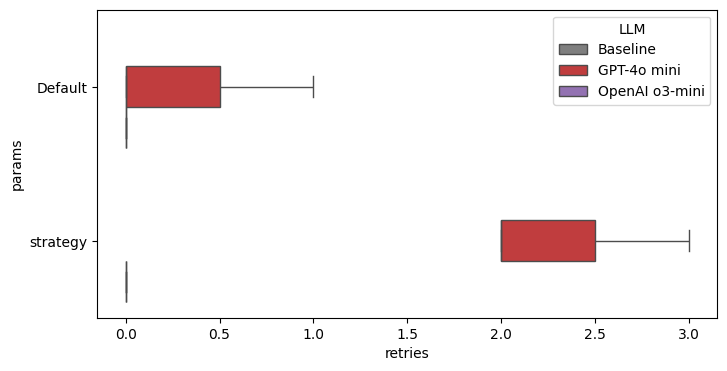

In [85]:
fig, ax = plt.subplots(figsize=(8, 4))
sns.boxplot(x="retries", y="params", hue="LLM", data=errors, ax=ax, palette=palette_LLM, hue_order=palette_LLM.keys())
plt.show()

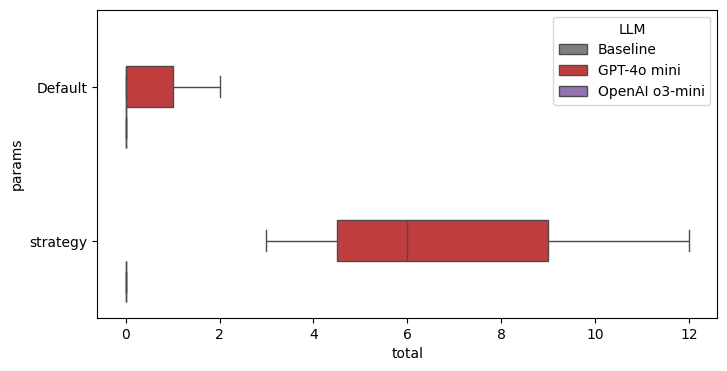

In [86]:
fig, ax = plt.subplots(figsize=(8, 4))
sns.boxplot(x="total", y="params", hue="LLM", data=errors, ax=ax, palette=palette_LLM, hue_order=palette_LLM.keys())
plt.show()

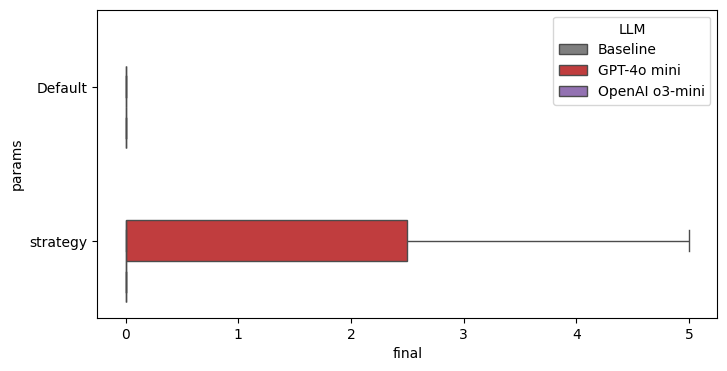

In [87]:
fig, ax = plt.subplots(figsize=(8, 4))
sns.boxplot(x="final", y="params", hue="LLM", data=errors, ax=ax, palette=palette_LLM, hue_order=palette_LLM.keys())
plt.show()

<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=6dddcb2f-9a74-4511-ab27-8e86504a138c' target="_blank">
 </img>
Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>